# LSTM-Based Sales Forecasting

## Objective

Develop an LSTM-based deep learning model to forecast
future daily sales using historical sales data.

## Dataset

Store Item Demand Forecasting Challenge

## Model

Long Short-Term Memory (LSTM)

## Forecasting Strategy

Use the previous 7 days of sales to predict the next day's sales.

Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

I0000 00:00:1789641381.300013    3595 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789641381.718778    3595 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789641383.654969    3595 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Load the dataset

In [4]:
df = pd.read_csv("../data/train.csv")

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [6]:
df.shape

(913000, 4)

### Understand the dataset

In [7]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [8]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [9]:
df["store"].nunique()

10

In [10]:
df["item"].nunique()

50

### Select one store and one item

In [11]:
store_id = 1
item_id = 1

sales_df = df[
    (df["store"] == store_id) &
    (df["item"] == item_id)
].copy()

In [15]:
sales_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [13]:
sales_df.shape

(1826, 4)

### Convert date

In [16]:
sales_df["date"] = pd.to_datetime(sales_df["date"])

In [17]:
sales_df = sales_df.sort_values("date")

In [18]:
sales_df.set_index("date", inplace=True)

In [19]:
sales_df.head()

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


### Keep only Sales

In [20]:
sales = sales_df[["sales"]]

In [21]:
sales.head()

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10


### Visualize the sales

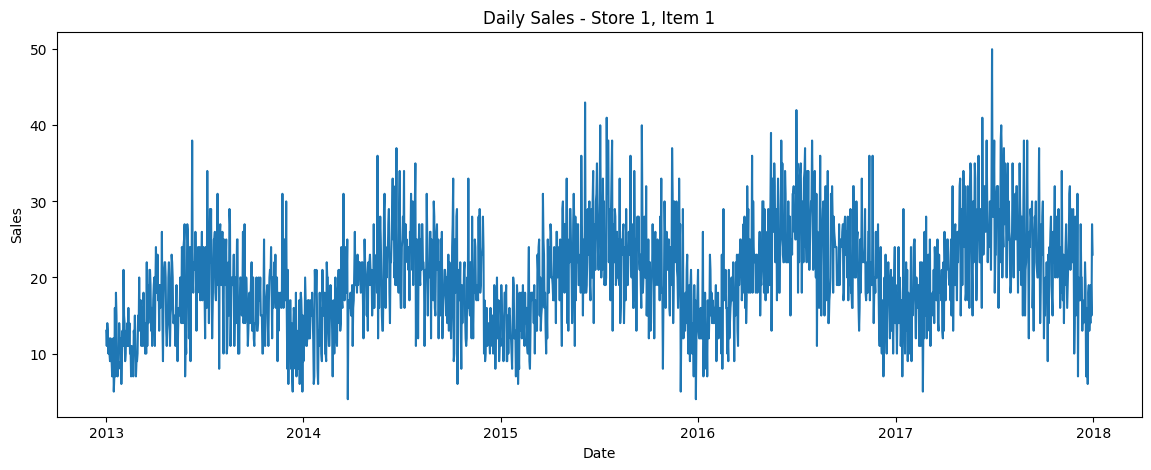

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(sales.index, sales["sales"])

plt.title("Daily Sales - Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Train/Test Split

80% → Training </br>
20% → Testing

In [24]:
train_size = int(len(sales) * 0.8)

train = sales.iloc[:train_size]
test = sales.iloc[train_size:]

print("Total samples:", len(sales))
print("Training samples:", len(train))
print("Testing samples:", len(test))

Total samples: 1826
Training samples: 1460
Testing samples: 366


### Visualize the split

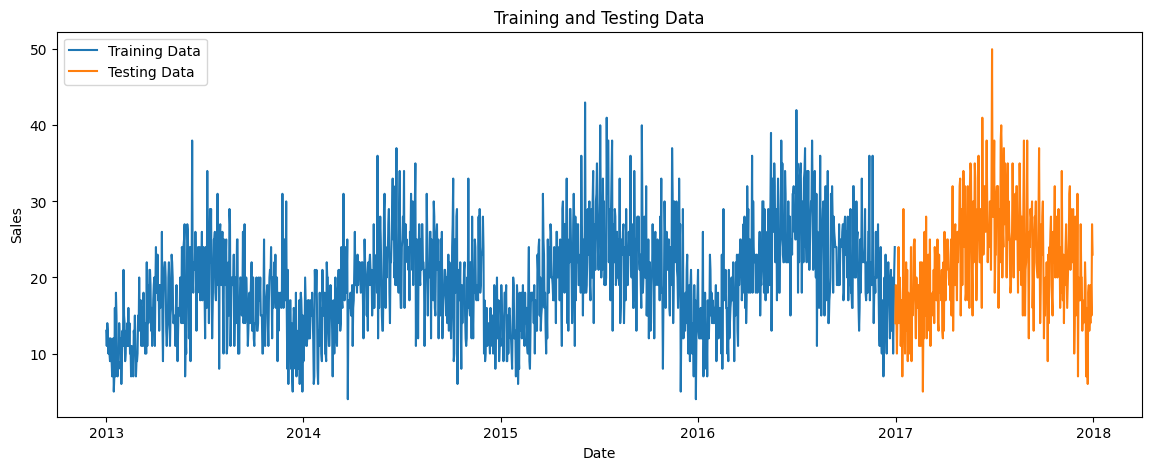

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train["sales"], label="Training Data")
plt.plot(test.index, test["sales"], label="Testing Data")

plt.title("Training and Testing Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

### Normalize the data
LSTMs generally train more effectively when the input values are scaled.

We'll use MinMaxScaler

In [26]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [27]:
print("Original sales:")
print(train.head())

print("\nScaled sales:")
print(train_scaled[:5])

Original sales:
            sales
date             
2013-01-01     13
2013-01-02     11
2013-01-03     14
2013-01-04     13
2013-01-05     10

Scaled sales:
[[0.23076923]
 [0.17948718]
 [0.25641026]
 [0.23076923]
 [0.15384615]]


## Create LSTM sequences

In [28]:
LOOKBACK = 7

Use the previous 7 days to predict the next day.

In [29]:
def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])

    return np.array(X), np.array(y)

In [30]:
LOOKBACK = 7

X_train, y_train = create_sequences(
    train_scaled,
    LOOKBACK
)

In [31]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1453, 7, 1)
y_train shape: (1453, 1)


### Prepare the test sequences correctly

In [32]:
test_input = np.concatenate(
    (train_scaled[-LOOKBACK:], test_scaled)
)

In [33]:
X_test, y_test = create_sequences(
    test_input,
    LOOKBACK
)

In [34]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (366, 7, 1)
y_test shape: (366, 1)


## Verify one sequence

In [35]:
print("First sequence:")
print(X_train[0])

print("\nTarget:")
print(y_train[0])

First sequence:
[[0.23076923]
 [0.17948718]
 [0.25641026]
 [0.23076923]
 [0.15384615]
 [0.20512821]
 [0.15384615]]

Target:
[0.12820513]


## Build the LSTM

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

Create model:

In [37]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(LOOKBACK, 1)),
    LSTM(50),
    Dense(1)
])

I0000 00:00:1789642172.127845    3595 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
/home/rohan/DL_Projects/LSTM-Sales-Forecasting/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(LOOKBACK, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


I0000 00:00:1789642335.566155    6308 cuda_dnn.cc:461] Loaded cuDNN version 92600


41/41 ━━━━━━━━━━━━━━━━━━━━ -4s 23ms/step - loss: 0.0459 - val_loss: 0.0203
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0191 - val_loss: 0.0204
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0188 - val_loss: 0.0205
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0191 - val_loss: 0.0206
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0184 - val_loss: 0.0206
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183 - val_loss: 0.0248
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0190 - val_loss: 0.0207
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183 - val_loss: 0.0207
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0182 - val_loss: 0.0233
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183 - val_loss: 0.0206
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0183 - val_loss: 0.0220
Epoch 12/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0180 - val_

### Plot training loss

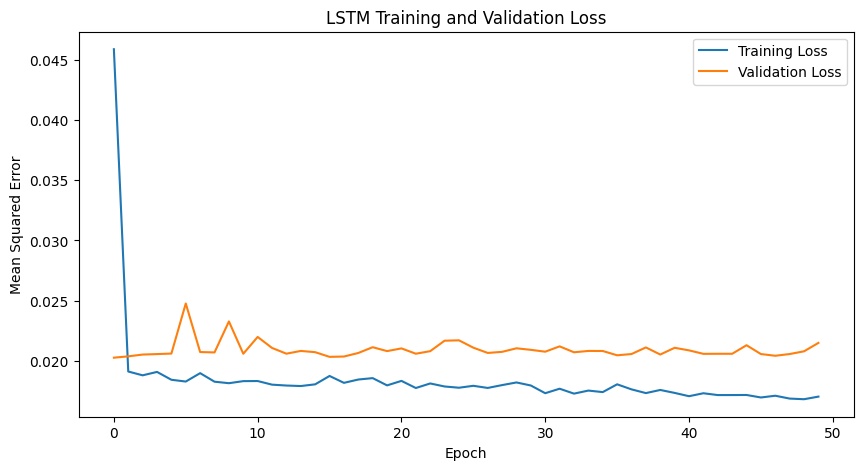

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.legend()
plt.show()

## Generate predictions

In [45]:
predictions_scaled = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [46]:
print(predictions_scaled.shape)

(366, 1)


## Convert predictions back to real sales

In [47]:
predictions = scaler.inverse_transform(predictions_scaled)

In [48]:
actual = scaler.inverse_transform(y_test)

In [49]:
print("Predicted:")
print(predictions[:10])

print("\nActual:")
print(actual[:10])

Predicted:
[[16.480967]
 [17.716297]
 [15.792159]
 [14.992397]
 [17.449541]
 [19.259794]
 [18.515697]
 [15.93459 ]
 [16.693354]
 [15.104123]]

Actual:
[[14.]
 [19.]
 [15.]
 [10.]
 [16.]
 [14.]
 [24.]
 [14.]
 [20.]
 [18.]]


### Calculate MAE and RMSE

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 4.426192843848891
RMSE: 5.567114609171335


## Plot Actual vs Predicted

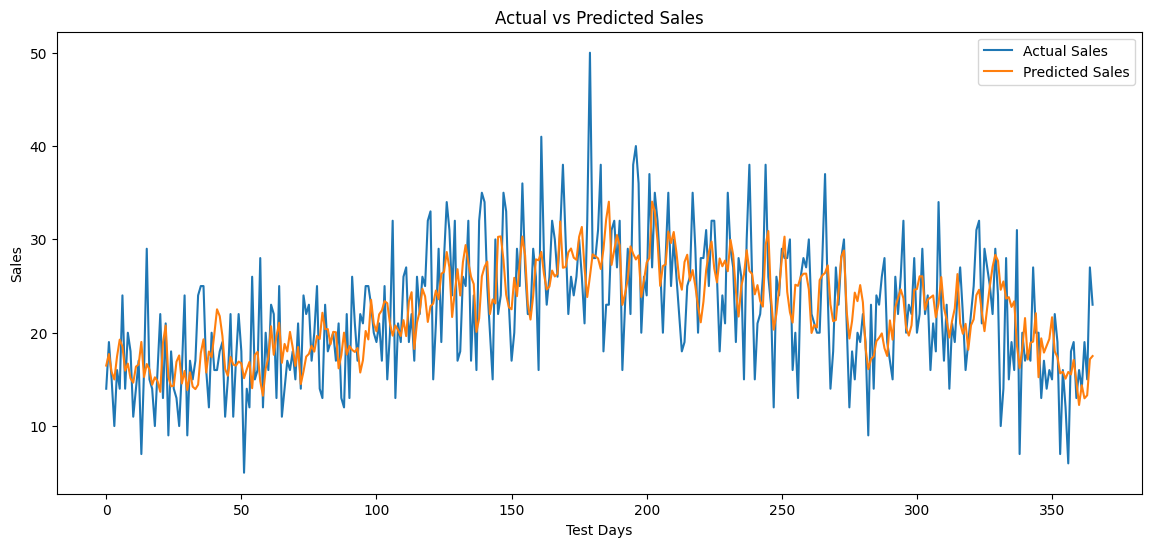

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(actual, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Days")
plt.ylabel("Sales")

plt.legend()
plt.show()

### Save the result graph

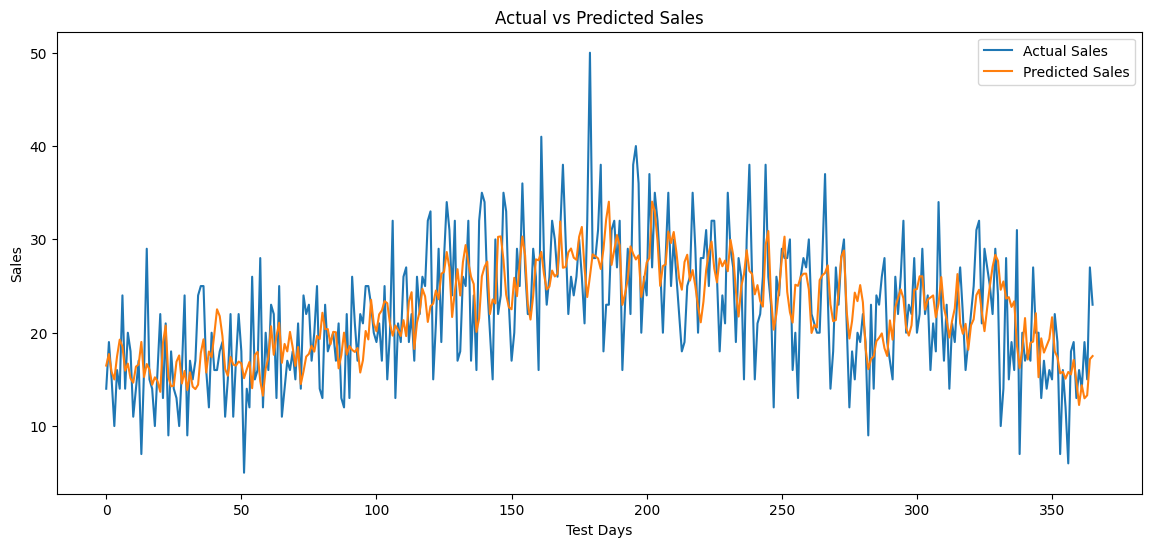

In [52]:
plt.figure(figsize=(14, 6))

plt.plot(actual, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Days")
plt.ylabel("Sales")

plt.legend()

plt.savefig("../results/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

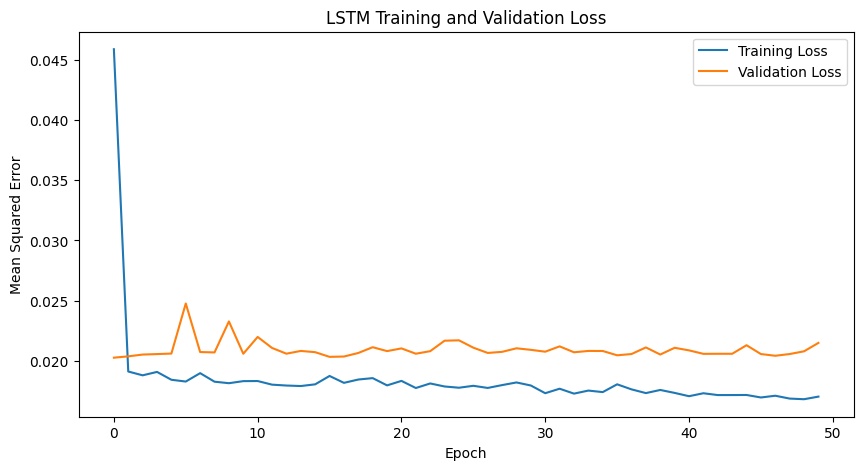

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.legend()

plt.savefig("../results/training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

## Save your results properly

In [54]:
results = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predictions.flatten()
})

results.head()

,Actual,Predicted
0,14.0,16.480967
1,19.0,17.716297
2,15.0,15.792159
3,10.0,14.992397
4,16.0,17.449541


In [55]:
results.to_csv("../results/predictions.csv", index=False)

### Save the trained model

In [56]:
model.save("../results/lstm_sales_model.keras")

### Create a metrics file

In [57]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [mae, rmse]
})

metrics

,Metric,Value
0,MAE,4.426193
1,RMSE,5.567115


In [58]:
metrics.to_csv("../results/metrics.csv", index=False)

## Conclusion

An LSTM-based deep learning model was developed for daily sales
forecasting using historical sales data.

The model used the previous 7 days of sales to predict the next
day's sales. The dataset was chronologically divided into training
and testing sets, and MinMaxScaler was used for normalization.

The model achieved:

- MAE: 4.4262
- RMSE: 5.5671

The actual versus predicted graph was used to visually evaluate
the forecasting performance.

The experiment demonstrates how LSTM networks can be applied to
time-series forecasting problems.